# UC1: Charting gamma-secretase substrates

**Reproduce the key result of a published study with AAanalysis.** This use case
walks the central finding of

> Breimann *et al.*, *Charting gamma-secretase substrates by explainable AI*,
> **Nature Communications** 16, 5428 (2025). https://doi.org/10.1038/s41467-025-60638-z

— the paper that AAanalysis was built to support — and reproduces it end-to-end
from **bundled data only** (no downloads). Where a *tutorial* teaches one tool and
a *protocol* teaches one workflow, a **use case** re-runs a real study: it shows
that a published result drops out of the standard AAanalysis pipeline, and it is
the template you adapt to your own paper-style analysis.

**The question.** *gamma-secretase* is an intramembrane protease implicated in
Alzheimer's disease and cancer. It cleaves only a subset of single-span membrane
proteins, with **no consensus sequence motif** marking which ones. The paper asks:
*what physicochemically distinguishes a gamma-secretase substrate from a
non-substrate, and can we predict substrates from sequence alone?*

**The answer, in one sentence.** *Comparative Physicochemical Profiling* (CPP)
finds an interpretable, position-resolved **signature** that separates substrates
from non-substrates and, fed to a tree model, predicts substrate status at
**~85% balanced accuracy** — far above a scale-average baseline that ignores
*where* in the sequence a property sits.

**What this reproduces (key results, simplified).**

| Paper figure | Reproduced here |
| --- | --- |
| Fig. 2b/2c — CPP profile & feature map | the gamma-secretase **signature** over the TMD-JMD parts |
| Fig. 3a — CPP vs. scale-based benchmark | **CPP ~85%** vs. **scale-average baseline ~75%** balanced accuracy |
| Fig. 2d / text — conformational, cleavage-region features dominate | the signature's **part** and **category** breakdown |

**Simplifications (so it runs in seconds on bundled data).** The paper trains on
the **imbalanced** human N-out proteome (63 expert substrates vs. 631 others, then
dPULearn-balanced) across **ten** model types with leave-one-out CV, and compares
**three** transmembrane annotations (UniProt / TMHMM / Phobius). Here we use the
bundled, **balanced** `DOM_GSEC` set (63 substrates + 63 non-substrates) with its
single embedded TMD/JMD annotation, one tree ensemble, and 5-fold cross-validation.
The headline number (~85% for CPP, matching the paper's 84%) and the biology
(cleavage-region, conformational features) reproduce; the absolute baseline gap is
narrower than the paper's because this set is balanced and proteome-free. Scaling
to the full study is exactly the *Protocols* (P1, P4, P8-P10).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

## 1. Load the gamma-secretase dataset

`DOM_GSEC` is a **domain-level** (`DOM_`) benchmark: one row per protein, a binary
`label` (1 = substrate / **test group**, 0 = non-substrate / **reference group**),
and the transmembrane geometry (`tmd_start` / `tmd_stop`) plus the pre-cut
`jmd_n` / `tmd` / `jmd_c` parts. It is the bundled, balanced subset behind the
paper's Fig. 2-3 (63 substrates + 63 non-substrates).

In [2]:
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
n_sub = sum(labels)
print(f"{df_seq.shape[0]} proteins: {n_sub} substrates (label=1) + {len(labels) - n_sub} non-substrates (label=0)")
aa.display_df(df=df_seq, n_rows=10, show_shape=True)

126 proteins: 63 substrates (label=1) + 63 non-substrates (label=0)
DataFrame shape: (126, 8)


,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,P05067,MLPGLALLLLAAWTA...GYENPTYKFFEQMQN,1,701,723,FAEDVGSNKG,AIIGLMVGGVVIATVIVITLVML,KKKQYTSIHH
2,P14925,MAGRARSGLLLLLLG...EEEYSAPLPKPAPSS,1,868,890,KLSTEPGSGV,SVVLITTLLVIPVLVLLAIVMFI,RWKKSRAFGD
3,P70180,MRSLLLFTFSACVLL...RELREDSIRSHFSVA,1,477,499,PCKSSGGLEE,SAVTGIVVGALLGAGLLMAFYFF,RKKYRITIER
4,Q03157,MGPTSPAARGQGRRW...HGYENPTYRFLEERP,1,585,607,APSGTGVSRE,ALSGLLIMGAGGGSLIVLSLLLL,RKKKPYGTIS
5,Q06481,MAATGTAAAAATGRL...GYENPTYKYLEQMQI,1,694,716,LREDFSLSSS,ALIGLLVIAVAIATVIVISLVML,RKRQYGTISH
6,P35613,MAAALFVLLGFALLG...HQNDKGKNVRQRNSS,1,323,345,IITLRVRSHL,AALWPFLGIVAEVLVLVTIIFIY,EKRRKPEDVL
7,P35070,MDRAARCSGASSLPL...DITPINEDIEETNIA,1,119,141,LFYLRGDRGQ,ILVICLIAVMVVFIILVIGVCTC,CHPLRKRRKR
8,P09803,MGARCRSFSALLLLL...RFKKLADMYGGGEDD,1,711,733,GIVAAGLQVP,AILGILGGILALLILILLLLLFL,RRRTVVKEPL
9,P19022,MCRIAGALRTLLPLL...PRFKKLADMYGGGDD,1,724,746,RIVGAGLGTG,AIIAILLCIIILLILVLMFVVWM,KRRDKERQAK
10,P16070,MDKFWWHAAWGLCLV...DETRNLQNVDMKIGV,1,650,672,GPIRTPQIPE,WLIILASLLALALILAVCIAVNS,RRRCGQKKKL


## 2. CPP: find the physicochemical signature

CPP splits each sequence into **parts** (`jmd_n` / `tmd` / `jmd_c`), applies
**splits** (position selectors) within each part, averages an amino-acid **scale**
over those positions, and keeps the `Part-Split-Scale` features that best separate
substrates from non-substrates. The result — the **signature** — is interpretable
biology, not a black box. (Mechanics: the `CPP` tutorial; workflow: *Protocol 1*.)

In [3]:
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)

cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=100, n_jobs=1)
print(f"signature: {df_feat.shape[0]} features")
aa.display_df(df=df_feat, n_rows=8, show_shape=True)

signature: 100 features
DataFrame shape: (100, 13)


,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",Conformation,α-helix,α-helix (middle),"Weights for alp...ejnowski, 1988)",0.387000,0.118000,0.118000,0.068000,0.080000,0.000000,0.000000,"27,28,29,30,31,32,33"
2,"TMD_C_JMD_C-Pat...,14)-CRAJ730103",Conformation,β-turn,β-turn,"Normalized freq...d et al., 1973)",0.377000,0.285000,-0.285000,0.164000,0.177000,0.000000,0.000000,"27,31"
3,"TMD_C_JMD_C-Seg...6,9)-FAUJ880104",Shape,Side chain length,Steric parameter,"STERIMOL length...e et al., 1988)",0.367000,0.263000,0.263000,0.161000,0.168000,0.000000,0.000000,"32,33"
4,"TMD_C_JMD_C-Seg...6,9)-ONEK900101",Others,Unclassified (Others),ΔG values in peptides,"Delta G values ...-DeGrado, 1990)",0.366000,0.111000,0.111000,0.070000,0.114000,0.000000,0.000000,"32,33"
5,"TMD_C_JMD_C-Pat...,15)-QIAN880107",Conformation,α-helix,α-helix (middle),"Weights for alp...ejnowski, 1988)",0.363000,0.162000,0.162000,0.091000,0.118000,0.000000,0.000000,"24,28,32,35"
6,"TMD_C_JMD_C-Seg...3,4)-HUTJ700103",Energy,Entropy,Entropy,"Entropy of form...Hutchens, 1970)",0.360000,0.187000,0.187000,0.115000,0.128000,0.000000,0.000000,"31,32,33,34,35"
7,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal prope...d et al., 1987)",0.359000,0.159000,-0.159000,0.090000,0.130000,0.000000,0.000000,"27,28,29,30,31,32,33"
8,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",Conformation,β-turn,β-turn,"Normalized freq...d et al., 1973)",0.352000,0.227000,-0.227000,0.150000,0.170000,0.000000,0.000000,"24,28,32"


## 3. Rank the signature by importance

Fit a `TreeModel` (a random-forest ensemble — the paper's family) on the CPP
feature matrix and attach a Monte-Carlo **feature importance** column. This is the
unsigned, group-level ranking that drives the figures below.

In [4]:
X_cpp = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)

tm = aa.TreeModel()
tm = tm.fit(X_cpp, labels=labels)
df_feat = tm.add_feat_importance(df_feat=df_feat)
aa.display_df(
    df=df_feat[["feature", "category", "subcategory", "mean_dif", "abs_auc", "feat_importance"]],
    n_rows=8, show_shape=True,
)

DataFrame shape: (100, 6)


,feature,category,subcategory,mean_dif,abs_auc,feat_importance
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",Conformation,α-helix,0.118000,0.387000,4.453000
2,"TMD_C_JMD_C-Pat...,14)-CRAJ730103",Conformation,β-turn,-0.285000,0.377000,3.463000
3,"TMD_C_JMD_C-Seg...6,9)-FAUJ880104",Shape,Side chain length,0.263000,0.367000,3.273000
4,"TMD_C_JMD_C-Seg...6,9)-ONEK900101",Others,Unclassified (Others),0.111000,0.366000,1.296000
5,"TMD_C_JMD_C-Pat...,15)-QIAN880107",Conformation,α-helix,0.162000,0.363000,2.491000
6,"TMD_C_JMD_C-Seg...3,4)-HUTJ700103",Energy,Entropy,0.187000,0.360000,1.858000
7,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",Others,PC 4,-0.159000,0.359000,1.786000
8,"TMD_C_JMD_C-Pat...,12)-CRAJ730103",Conformation,β-turn,-0.227000,0.352000,2.637000


## 4. The signature as a feature map (cf. Fig. 2c)

Rows = scale **subcategories**, columns = **positions** along the parts, colour =
`mean_dif` (direction & strength of the substrate-vs-non-substrate difference), top
bars = cumulative feature importance. Read coherent **blocks** (one property family,
one region), not single cells.

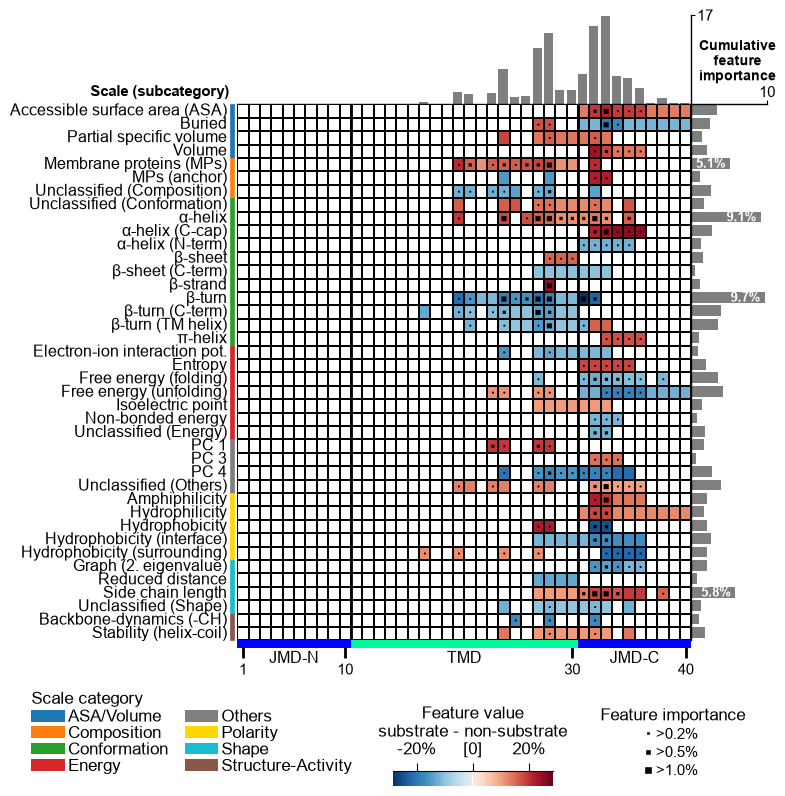

In [5]:
cpp_plot = aa.CPPPlot()
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat, name_test="substrate", name_ref="non-substrate")
plt.tight_layout()
plt.show()

## 5. The CPP profile (cf. Fig. 2b)

The profile collapses the map onto the sequence axis: cumulative feature importance
per position. The signal concentrates around the **cleavage region** in the
C-terminal TMD / JMD-C — exactly where the paper localises the substrate signature.

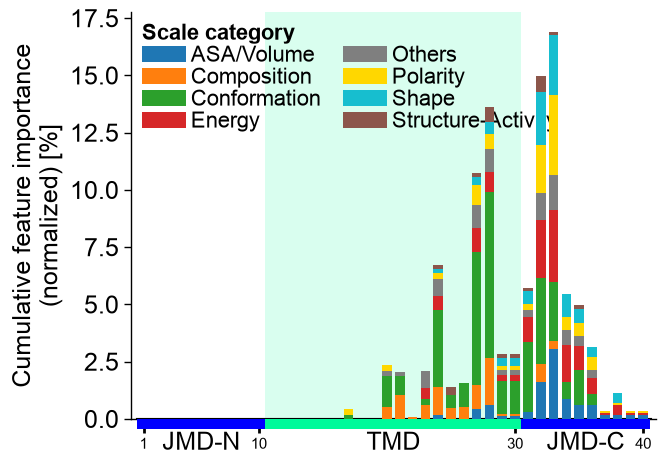

In [6]:
aa.plot_settings()
cpp_plot.profile(df_feat=df_feat, add_legend_cat=True)
plt.tight_layout()
plt.show()

## 6. Benchmark: CPP vs. a scale-average baseline (cf. Fig. 3a)

The paper's core claim is that **positional splitting matters**: averaging
physicochemical scales over the *whole* sequence (the "scale-based" baseline) throws
away *where* a property sits, while CPP keeps it. We compare, apples-to-apples with
the same tree model and 5-fold cross-validation:

- **CPP** — the `Part-Split-Scale` signature from step 2.
- **Scale-based** — each amino-acid scale averaged across the whole TMD-JMD sequence
  (no splits), the baseline described in the paper's Methods.

In [7]:
# Scale-based baseline: average every scale over the whole TMD-JMD sequence (no splits)
df_scales = aa.load_scales()
seqs = (df_seq["jmd_n"] + df_seq["tmd"] + df_seq["jmd_c"]).to_list()
X_scale = np.array([df_scales.loc[[a for a in s if a in df_scales.index]].mean(axis=0).values for s in seqs])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
def balanced_acc(X):
    y_pred = cross_val_predict(RandomForestClassifier(n_estimators=200, random_state=42),
                               X, labels, cv=cv)
    return balanced_accuracy_score(labels, y_pred) * 100

bacc_cpp = balanced_acc(X_cpp)
bacc_scale = balanced_acc(X_scale)
print(f"CPP            ({X_cpp.shape[1]:>3d} features): {bacc_cpp:.1f}% balanced accuracy")
print(f"Scale-based    ({X_scale.shape[1]:>3d} features): {bacc_scale:.1f}% balanced accuracy")

CPP            (100 features): 84.9% balanced accuracy
Scale-based    (586 features): 75.4% balanced accuracy


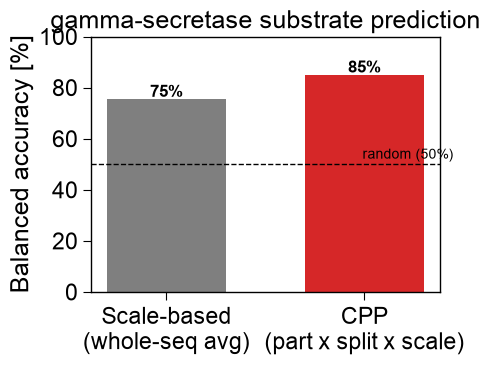

In [8]:
aa.plot_settings()
fig, ax = plt.subplots(figsize=(5, 4))
names = ["Scale-based\n(whole-seq avg)", "CPP\n(part x split x scale)"]
vals = [bacc_scale, bacc_cpp]
bars = ax.bar(names, vals, color=["tab:gray", "tab:red"], width=0.6)
ax.axhline(50, ls="--", color="black", lw=1)
ax.text(1.45, 51, "random (50%)", ha="right", va="bottom", fontsize=10)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center", fontsize=12, weight="bold")
ax.set_ylabel("Balanced accuracy [%]")
ax.set_ylim(0, 100)
ax.set_title("gamma-secretase substrate prediction")
plt.tight_layout()
plt.show()

## 7. Where the signature lives (cf. Fig. 2b/2d)

The paper reports that substrate-defining features cluster in the **cleavage region**
(C-terminal TMD into JMD-C) and that **conformational** properties dominate. The same
falls out of our signature: most features map to the `TMD_C_JMD_C` part, and
*Conformation* is the leading scale category.

In [9]:
part = df_feat["feature"].str.split("-").str[0].value_counts()
print("Features per part:")
for p, c in part.items():
    print(f"  {p:<14s}: {c:>3d}  ({c / len(df_feat) * 100:.0f}%)")
print("\nFeatures per AAontology category:")
for cat, c in df_feat["category"].value_counts().items():
    print(f"  {cat:<20s}: {c:>3d}")

Features per part:
  TMD_C_JMD_C   :  85  (85%)
  TMD           :  15  (15%)

Features per AAontology category:
  Conformation        :  31
  Energy              :  13
  Polarity            :  12
  ASA/Volume          :  11
  Shape               :  10
  Others              :  10
  Composition         :  10
  Structure-Activity  :   3


## Summary

Reproduced from bundled data, in seconds:

- **CPP signature** — an interpretable, position-resolved feature set separating
  gamma-secretase substrates from non-substrates (steps 2-5).
- **~85% balanced accuracy** for CPP vs. **~75%** for the whole-sequence scale-average
  baseline — the same direction as the paper's Fig. 3a (84% vs. ~50-57% on the full
  imbalanced proteome): *positional splitting is what makes the difference*.
- **Biology matches** — the signature concentrates in the cleavage region
  (`TMD_C_JMD_C`) and is dominated by conformational properties, as the paper reports.

**Scale it up.** To approach the full study — the imbalanced proteome, dPULearn
non-substrate mining, multi-model leave-one-out CV, SHAP single-residue explanations,
and the proteome-wide substrate prediction — follow the **Protocols**: *P1 (CPP
signature)*, *P4 (engineer features)*, *P7-P8 (selection & prediction)*, and *P9-P10
(interpretability & validation)*.

> Breimann *et al.*, *Charting gamma-secretase substrates by explainable AI*,
> Nat. Commun. 16, 5428 (2025). https://doi.org/10.1038/s41467-025-60638-z